In [1]:
!pip install "dacite~=1.6.0" mlflow dagshub scikit-learn lightgbm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 74.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 70.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.sklearn
import dagshub
from mlflow.tracking import MlflowClient
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
REPO_OWNER   = 'ejoba22'
REPO_NAME    = 'IEEE-CIS-Fraud-Detection'

dagshub.init(repo_owner=REPO_OWNER, repo_name=REPO_NAME, mlflow=True)

if mlflow.active_run() is not None:
    mlflow.end_run()

client = MlflowClient()
print('MLflow tracking URI:', mlflow.get_tracking_uri())

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=9909c378-2ae8-4c2c-afb4-e36d6f999142&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=7050147ccc1b4bf89123ca25c19588416d11f3409bd10664cb0e16a6c41e8bd7




Accessing as ejoba22

Initialized MLflow to track repo "ejoba22/IEEE-CIS-Fraud-Detection"

Repository ejoba22/IEEE-CIS-Fraud-Detection initialized!

MLflow tracking URI: https://dagshub.com/ejoba22/IEEE-CIS-Fraud-Detection.mlflow


In [3]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            continue
        c_min = df[col].min()
        c_max = df[col].max()
        if str(col_type).startswith('int'):
            if   c_min >= np.iinfo(np.int8).min  and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        elif str(col_type).startswith('float'):
            df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f'Memory: {start_mem:.1f} MB → {end_mem:.1f} MB ({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')
    return df

# Model Registry

In [4]:
# All registered model names
REGISTERED_MODELS = [
    'IEEE_CIS_LogisticRegression_Best',
    'IEEE_CIS_RandomForest_Best',
    'IEEE_CIS_XGBoost_Best',
    'IEEE_CIS_LightGBM_Best',
    'IEEE_CIS_DecisionTree_Best',
]

results = []

for model_name in REGISTERED_MODELS:
    try:
        versions = client.get_latest_versions(model_name)
        if not versions:
            print(f'  {model_name}: no versions found, skipping.')
            continue
        latest = versions[0]
        run_id  = latest.run_id
        version = latest.version

        run_data = client.get_run(run_id)
        val_auc  = run_data.data.metrics.get('val_auc', None)
        gap      = run_data.data.metrics.get('overfit_gap', None)

        results.append({
            'model_name': model_name,
            'version':    version,
            'run_id':     run_id,
            'val_auc':    val_auc,
            'overfit_gap': gap,
        })
        print(f'  {model_name} v{version}  val_auc={val_auc}  gap={gap}')

    except Exception as e:
        print(f'  {model_name}: error — {e}')

results_df = pd.DataFrame(results).sort_values('val_auc', ascending=False)
print('\n--- Registry Comparison ---')
print(results_df.to_string(index=False))

  IEEE_CIS_LogisticRegression_Best v2  val_auc=0.8317  gap=0.0426
  IEEE_CIS_RandomForest_Best v1  val_auc=0.8737  gap=0.0598
  IEEE_CIS_XGBoost_Best v1  val_auc=0.8924  gap=0.0224
  IEEE_CIS_LightGBM_Best v2  val_auc=0.9195  gap=0.0757
  IEEE_CIS_DecisionTree_Best v1  val_auc=0.8428  gap=0.0764

--- Registry Comparison ---
                      model_name version                           run_id  val_auc  overfit_gap
          IEEE_CIS_LightGBM_Best       2 65c86645450b4767952974882b8dca81   0.9195       0.0757
           IEEE_CIS_XGBoost_Best       1 1d4edde001624e66a7e06389e80a552f   0.8924       0.0224
      IEEE_CIS_RandomForest_Best       1 d5c0cfed5b0f487c859580f723591c96   0.8737       0.0598
      IEEE_CIS_DecisionTree_Best       1 dc1eb34189d943f58437ba069ca0a69b   0.8428       0.0764
IEEE_CIS_LogisticRegression_Best       2 ac10d8255adb4a5b8bcab61e533d1f04   0.8317       0.0426


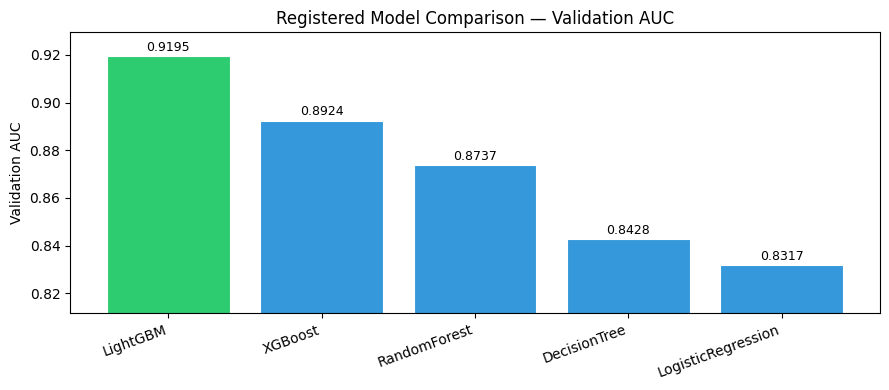

In [5]:
# Bar chart: val AUC per registered model
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if v == results_df['val_auc'].max() else '#3498db' for v in results_df['val_auc']]
bars = ax.bar(results_df['model_name'].str.replace('IEEE_CIS_', '').str.replace('_Best', ''),
              results_df['val_auc'], color=colors, edgecolor='white', linewidth=0.8)
ax.set_ylabel('Validation AUC')
ax.set_title('Registered Model Comparison — Validation AUC')
ax.set_ylim(results_df['val_auc'].min() - 0.02, results_df['val_auc'].max() + 0.01)
for bar, val in zip(bars, results_df['val_auc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
import os; os.makedirs('images', exist_ok=True)
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Pick the best model (highest val_auc)
best_row   = results_df.iloc[0]
BEST_MODEL = best_row['model_name']
BEST_AUC   = best_row['val_auc']

print(f'Best model : {BEST_MODEL}')
print(f'Val AUC    : {BEST_AUC:.4f}')
print(f'Overfit gap: {best_row["overfit_gap"]}')

model_uri = f'models:/{BEST_MODEL}/latest'
best_pipeline = mlflow.sklearn.load_model(model_uri)
print(f'\nLoaded pipeline from registry: {model_uri}')
print(best_pipeline)

Best model : IEEE_CIS_LightGBM_Best
Val AUC    : 0.9195
Overfit gap: 0.0757



Loaded pipeline from registry: models:/IEEE_CIS_LightGBM_Best/latest
Pipeline(steps=[('preprocess',
                 LightGBMFraudPreprocessor(feature_set='baseline',
                                           selection_strategy='variance_only')),
                ('model',
                 LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05,
                                min_child_samples=100, n_estimators=500,
                                n_jobs=-1, num_leaves=127, random_state=42,
                                reg_lambda=1.0, subsample=0.8, verbose=-1))])


## სრული Training Data-ს ჩატვირთვა

In [7]:
train_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_identity    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

train_full = train_transaction.merge(train_identity, on='TransactionID', how='left')
train_full = reduce_mem_usage(train_full)
train_full = train_full.sort_values('TransactionDT').reset_index(drop=True)

X_full = train_full.drop(columns=['isFraud'])
y_full = train_full['isFraud']

print(f'Full training set: {X_full.shape[0]:,} rows × {X_full.shape[1]} cols')
print(f'Fraud rate: {y_full.mean():.3%}')

Memory: 2514.0 MB → 1603.3 MB (36.2% reduction)
Full training set: 590,540 rows × 433 cols
Fraud rate: 3.499%


In [8]:
# Refit the best pipeline on the full training data
print(f'Refitting {BEST_MODEL} on full training set ({len(X_full):,} rows)...')
best_pipeline.fit(X_full, y_full)

# Sanity check: train AUC on full data (expected to be high — just confirms pipeline works)
train_preds = best_pipeline.predict_proba(X_full)[:, 1]
full_train_auc = roc_auc_score(y_full, train_preds)
print(f'Train AUC on full data: {full_train_auc:.4f}  (sanity check — not used for selection)')

Refitting IEEE_CIS_LightGBM_Best on full training set (590,540 rows)...
Train AUC on full data: 0.9928  (sanity check — not used for selection)


## Test Set-ზე Prediction

In [9]:
test_transaction = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_identity    = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

test = test_transaction.merge(test_identity, on='TransactionID', how='left')
test = reduce_mem_usage(test)
test = test.sort_values('TransactionDT').reset_index(drop=True)

print(f'Test set: {test.shape[0]:,} rows × {test.shape[1]} cols')
print(f'TransactionID range: {test["TransactionID"].min()} – {test["TransactionID"].max()}')

Memory: 2164.1 MB → 1386.1 MB (35.9% reduction)
Test set: 506,691 rows × 433 cols
TransactionID range: 3663549 – 4170239


In [10]:
def safe_predict_proba(pipeline, X):
    try:
        return pipeline.predict_proba(X)[:, 1]
    except ValueError as e:
        if 'categorical_feature' not in str(e):
            raise

        preprocessor = pipeline.named_steps['preprocess']
        model_step   = pipeline.named_steps['model']
        X_proc = preprocessor.transform(X)
        cat_cols     = [c for c in X_proc.columns if str(X_proc[c].dtype) == 'category']
        stored_cats  = model_step.booster_.pandas_categorical
        for col, train_cats in zip(cat_cols, stored_cats):
            X_proc[col] = pd.Categorical(X_proc[col], categories=train_cats)
        return model_step.predict_proba(X_proc)[:, 1]

X_test = test  
test_preds = safe_predict_proba(best_pipeline, X_test)

print(f'Predictions: min={test_preds.min():.4f}  max={test_preds.max():.4f}  mean={test_preds.mean():.4f}')
print(f'% predicted fraud (>0.5): {(test_preds > 0.5).mean():.3%}')

Predictions: min=0.0000  max=0.9988  mean=0.0136
% predicted fraud (>0.5): 1.056%


## Kaggle Submission

In [11]:
submission = pd.DataFrame({
    'TransactionID': test['TransactionID'],
    'isFraud':       test_preds
})

submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved — {len(submission):,} rows')
print(submission.head(10).to_string(index=False))

submission.csv saved — 506,691 rows
 TransactionID  isFraud
       3663549 0.000704
       3663550 0.000375
       3663551 0.000654
       3663552 0.000339
       3663553 0.000290
       3663554 0.001256
       3663555 0.000844
       3663556 0.002266
       3663557 0.000134
       3663558 0.002829


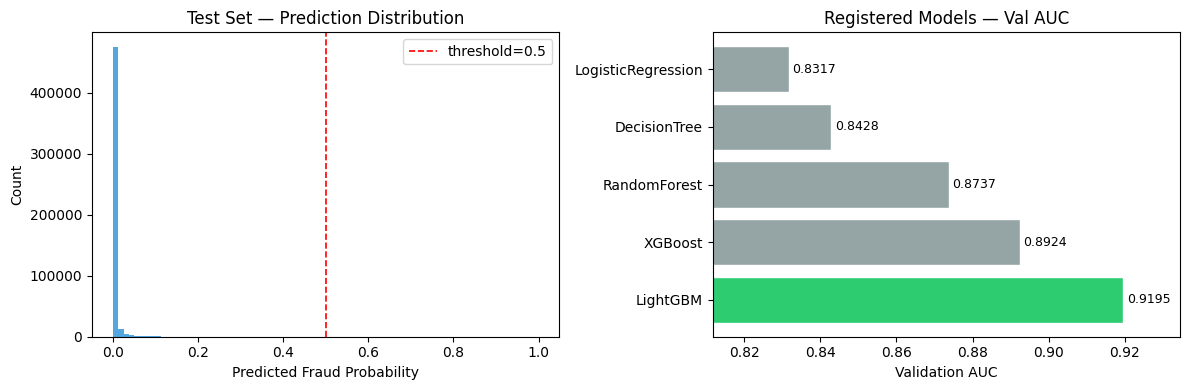


Final submission generated with model: IEEE_CIS_LightGBM_Best
Val AUC of selected model: 0.9195


In [12]:
# Prediction score distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(test_preds, bins=80, color='#3498db', edgecolor='none', alpha=0.85)
axes[0].set_xlabel('Predicted Fraud Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Test Set — Prediction Distribution')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='threshold=0.5')
axes[0].legend()

# Model comparison chart (replot from above for completeness)
colors = ['#2ecc71' if v == results_df['val_auc'].max() else '#95a5a6' for v in results_df['val_auc']]
axes[1].barh(
    results_df['model_name'].str.replace('IEEE_CIS_', '').str.replace('_Best', ''),
    results_df['val_auc'],
    color=colors, edgecolor='white'
)
axes[1].set_xlabel('Validation AUC')
axes[1].set_title('Registered Models — Val AUC')
axes[1].set_xlim(results_df['val_auc'].min() - 0.02, results_df['val_auc'].max() + 0.015)
for i, (val, name) in enumerate(zip(results_df['val_auc'], results_df['model_name'])):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
import os; os.makedirs('images', exist_ok=True)
plt.savefig('images/inference_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nFinal submission generated with model: {BEST_MODEL}')
print(f'Val AUC of selected model: {BEST_AUC:.4f}')